In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("../data/IRIS.csv")

In [25]:
# method 1
def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

rng = np.random.default_rng()
train_set, test_set = shuffle_and_split_data(df, 0.2, rng)

# method 2
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

flowers_with_id = df.reset_index()  # adds an `index` column
train_set, test_set = split_data_with_id_hash(flowers_with_id, 0.2, "index")

# method 3
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [32]:
train_df[train_df["species"]=="Iris-versicolor"]

,sepal_length,sepal_width,petal_length,petal_width,species
73,6.1,2.8,4.7,1.2,Iris-versicolor
78,6.0,2.9,4.5,1.5,Iris-versicolor
76,6.8,2.8,4.8,1.4,Iris-versicolor
64,5.6,2.9,3.6,1.3,Iris-versicolor
68,6.2,2.2,4.5,1.5,Iris-versicolor
82,5.8,2.7,3.9,1.2,Iris-versicolor
56,6.3,3.3,4.7,1.6,Iris-versicolor
69,5.6,2.5,3.9,1.1,Iris-versicolor
55,5.7,2.8,4.5,1.3,Iris-versicolor
65,6.7,3.1,4.4,1.4,Iris-versicolor


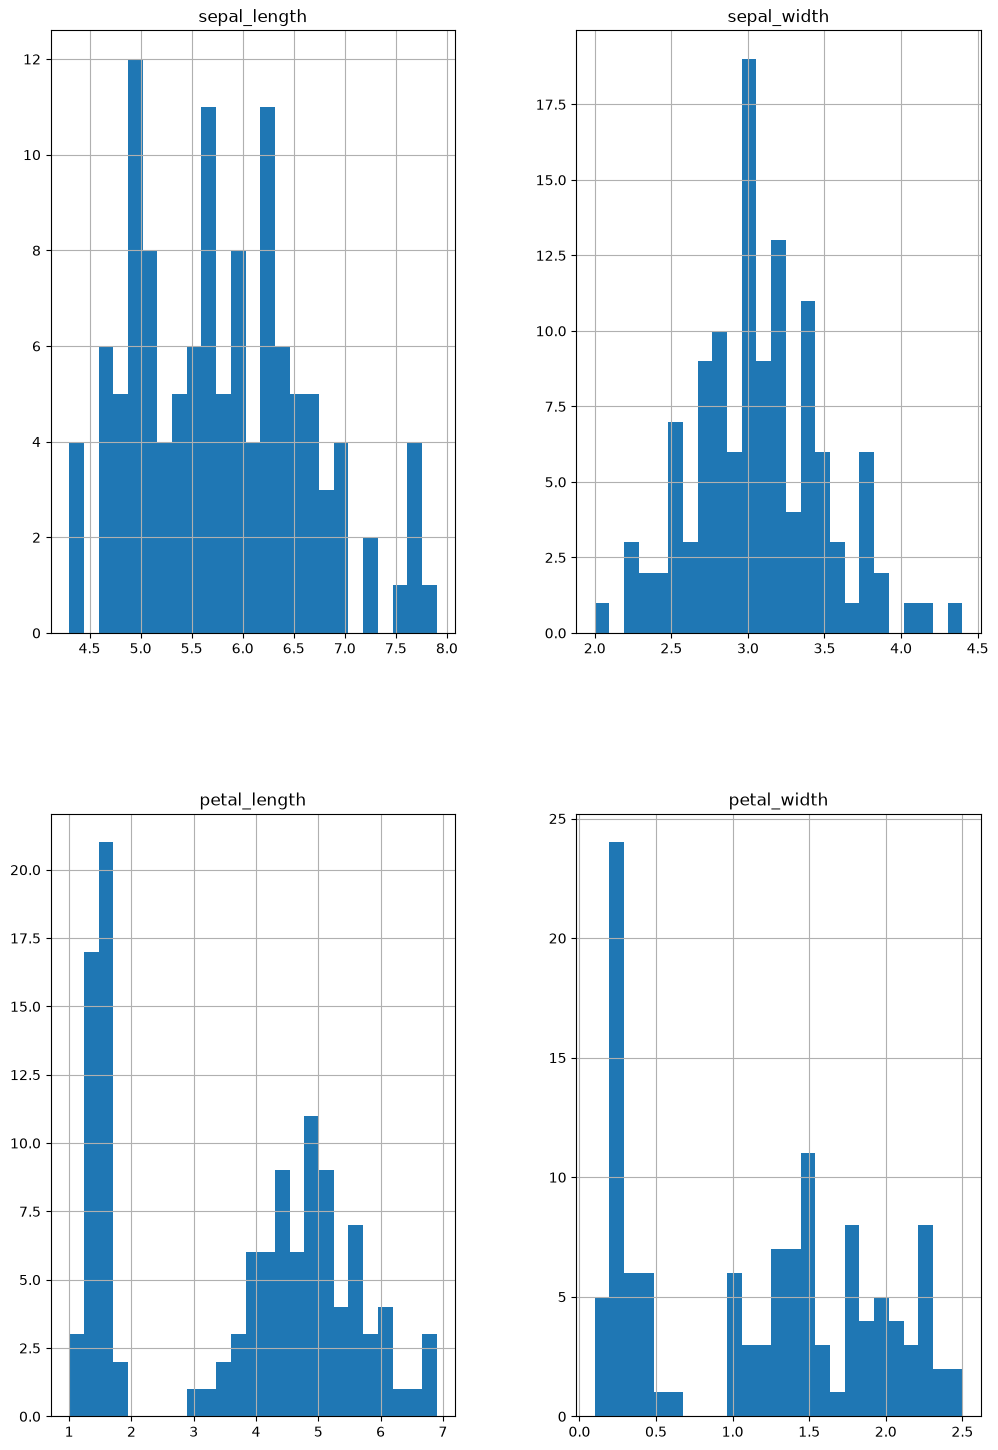

In [33]:
train_df.hist(bins=25, figsize=(12, 18))
plt.show()